# UAE with MNIST (Random Missing Pixels)

This notebook builds an MNIST dataset where each sample contains:
- channel 0: masked image
- channel 1: binary mask (1=observed, 0=missing)

Final input shape: `(n, 2, img_size, img_size)`.


In [1]:
import os
import sys

repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
else:
    sys.path.remove(repo_root)
    sys.path.insert(0, repo_root)

# Avoid stale site-packages imports when editing local pypots code
for k in list(sys.modules.keys()):
    if k == "pypots" or k.startswith("pypots."):
        del sys.modules[k]

print("Using repo root:", repo_root)


Using repo root: /Users/vincente/Documents/Vie Pro/Phd/Code/Code_pour_manuscript/PyPOTS


In [2]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)


In [3]:
# Config
img_size = 28
missing_prob = 0.15  # probability a pixel is hidden
batch_size = 128
root = './data'

transform = transforms.Compose([
    transforms.ToTensor(),  # -> [1, 28, 28], values in [0, 1]
])

train_ds = datasets.MNIST(root=root, train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root=root, train=False, download=True, transform=transform)


In [4]:
def build_masked_inputs(mnist_dataset, missing_prob=0.4):
    # Stack all samples into tensors
    images = torch.stack([img for img, _ in mnist_dataset], dim=0)  # [N, 1, H, W]
    labels = torch.tensor([label for _, label in mnist_dataset], dtype=torch.long)

    # Binary observation mask: 1 observed, 0 missing
    mask = (torch.rand_like(images) > missing_prob).float()  # [N, 1, H, W]

    # Apply mask
    masked_images = images * mask

    # Input with 2 channels: [masked_image, mask]
    x_in = torch.cat([masked_images, mask], dim=1)  # [N, 2, H, W]

    return x_in, images, mask, labels

x_train, x_train_full, m_train, y_train = build_masked_inputs(train_ds, missing_prob)
x_test, x_test_full, m_test, y_test = build_masked_inputs(test_ds, missing_prob)

print('x_train shape:', tuple(x_train.shape))
print('x_test shape :', tuple(x_test.shape))


x_train shape: (60000, 2, 28, 28)
x_test shape : (10000, 2, 28, 28)


In [5]:
# Optional: wrap in DataLoader
train_tensor_ds = TensorDataset(x_train, x_train_full, m_train, y_train)
test_tensor_ds = TensorDataset(x_test, x_test_full, m_test, y_test)

train_loader = DataLoader(train_tensor_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_tensor_ds, batch_size=batch_size, shuffle=False)

xb, xfull_b, mb, yb = next(iter(train_loader))
print('Batch input shape:', tuple(xb.shape))  # [B, 2, 28, 28]


Batch input shape: (128, 2, 28, 28)


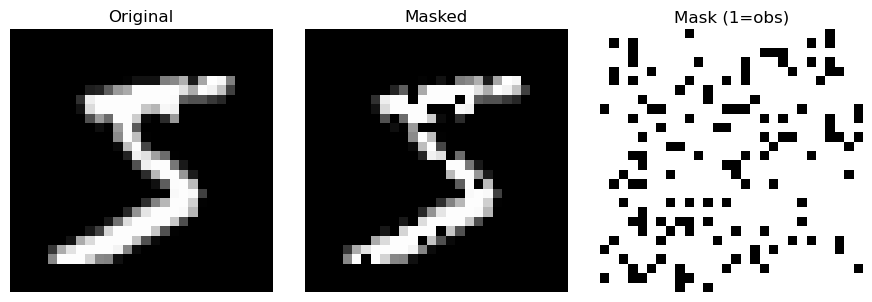

In [6]:
# Quick visual check on one sample
i = 0
masked_img = x_train[i, 0]
mask_img = x_train[i, 1]
full_img = x_train_full[i, 0]

fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].imshow(full_img, cmap='gray')
ax[0].set_title('Original')
ax[1].imshow(masked_img, cmap='gray')
ax[1].set_title('Masked')
ax[2].imshow(mask_img, cmap='gray')
ax[2].set_title('Mask (1=obs)')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()


## Train GP-UAE2 on MNIST (uncertainty encoder)

In [7]:
# Build GP_UAE2-ready train/val dicts with explicit masks and time axis
n_steps = 10
n_train = 500
n_val = 500

x_train_ts = x_train[:n_train, 0].unsqueeze(1).repeat(1, n_steps, 1, 1).float()
m_train_ts = x_train[:n_train, 1].unsqueeze(1).repeat(1, n_steps, 1, 1).float()

x_val_ts = x_test[:n_val, 0].unsqueeze(1).repeat(1, n_steps, 1, 1).float()
m_val_ts = x_test[:n_val, 1].unsqueeze(1).repeat(1, n_steps, 1, 1).float()

train_set = {
    'X': x_train_ts,
    'mask': m_train_ts,
}

val_set = {
    'X': x_val_ts,
    'mask': m_val_ts,
    'X_ori': x_val_ts.clone(),
    'indicating_mask': torch.zeros_like(x_val_ts),
}

print('train_set X shape:', tuple(train_set['X'].shape))
print('train_set mask shape:', tuple(train_set['mask'].shape))
print('val_set X shape:', tuple(val_set['X'].shape))


train_set X shape: (500, 10, 28, 28)
train_set mask shape: (500, 10, 28, 28)
val_set X shape: (500, 10, 28, 28)


In [8]:
# Backward-compatible aliases for older cells below
x_train_dict = train_set
x_test_dict = val_set

print('x_train_dict keys:', list(x_train_dict.keys()))
print('x_test_dict keys :', list(x_test_dict.keys()))


x_train_dict keys: ['X', 'mask']
x_test_dict keys : ['X', 'mask', 'X_ori', 'indicating_mask']


In [19]:
from pypots.imputation import GP_UAE2
import torch
from pypots.optim.adam import Adam


device = 'cuda' if torch.cuda.is_available() else 'cpu'

gpuae = GP_UAE2(
            #pretrained_weights_path="outputs/ae_weights.pth",
            #load_backbone_only=True,
            #freeze_loaded_backbone=False,
            n_steps=n_steps,
            n_features=28*28,
            latent_size=32,
            epochs=20,
            batch_size=64,
            alpha=.9,
            beta=0,  # no KL term for now
            sigma=1e-2,
            K=1,
            encoder_sizes=(64, 128),
            decoder_sizes=(128, 64),
            optimizer=Adam(weight_decay=1e-5, lr=1e-3),
            patience=20,
            p=0.0,
            device=device,
            verbose=True,
            visualization_dir="outputs/gpuae_visu"
        )

gpuae.fit(train_set=x_train_dict, val_set=x_test_dict)


2026-03-07 17:59:16 [INFO]: Using the given device: cpu
2026-03-07 17:59:16 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2026-03-07 17:59:16 [INFO]: GP_UAE2 initialized with the given hyperparameters, the number of trainable parameters: 3,859,329
2026-03-07 17:59:38 [INFO]: Epoch 001 - training loss: 0.1587, validation loss: 0.1011, train nll: 0.1587, train kl: 493.6305, val nll: 0.1011, val kl: 3780.8707
2026-03-07 18:00:02 [INFO]: Epoch 002 - training loss: 0.1078, validation loss: 0.1024, train nll: 0.1078, train kl: 23891.8513, val nll: 0.1024, val kl: 68828.3477
2026-03-07 18:00:10 [ERROR]: ❌ Exception: Expected parameter loc (Tensor of shape (64, 10, 32)) of distribution Normal(loc: torch.Size([64, 10, 32]), scale: torch.Size([64, 10, 32])) to satisfy the constraint Real(), but found invalid values:
tensor([[[nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan]

In [ ]:
gpuae.save_weights("outputs/ae_weights.pth")


In [ ]:
gpuae.beta = 1e-5  # add KL term after initial training
gpuae.p = 0.1  # add some input noise for robustness
gpuae.fit(train_set=x_train_dict, val_set=x_test_dict)


In [ ]:
gpuae.save_weights("outputs/ae_weights.pth")

vae_model = GP_UAE2(
    pretrained_weights_path="outputs/ae_weights.pth",
    load_backbone_only=True,
    freeze_loaded_backbone=False,  # set True if you want to freeze encoder/decoder
)


2026-03-07 17:43:24 [INFO]: Saved GP_UAE2 weights to outputs/ae_weights.pth
2026-03-07 17:43:24 [INFO]: Saved GP_UAE2 weights to outputs/ae_weights.pth


TypeError: GP_UAE2.__init__() missing 3 required positional arguments: 'n_steps', 'n_features', and 'latent_size'

prediction shape: (16, 10, 28, 28)


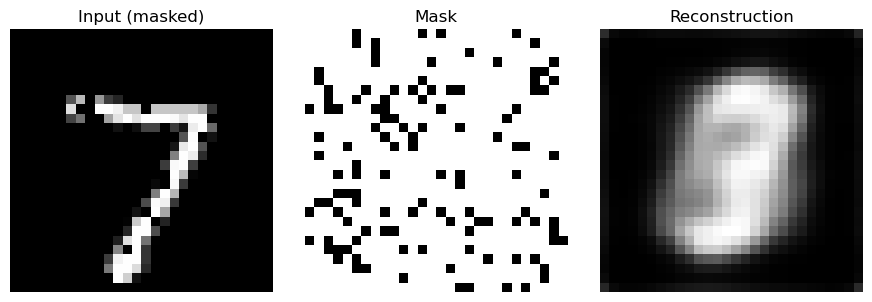

In [15]:
# Quick reconstruction / imputation output for GP_UAE2 image-sequence format
import torch
import matplotlib.pyplot as plt

if 'gpuae' not in globals():
    raise RuntimeError('gpuae is not defined. Run the training cell above first.')

n_eval = min(16, int(val_set['X'].shape[0]))
pred = gpuae.predict({'X': val_set['X'][:n_eval], 'mask': val_set['mask'][:n_eval]}, with_gp=False)
x_hat = torch.from_numpy(pred['imputation']).float()  # [N, T, 28, 28]

print('prediction shape:', tuple(x_hat.shape))

sample_idx = 0
time_idx = 0
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].imshow(val_set['X'][sample_idx, time_idx].cpu(), cmap='gray')
ax[0].set_title('Input (masked)')
ax[1].imshow(val_set['mask'][sample_idx, time_idx].cpu(), cmap='gray')
ax[1].set_title('Mask')
ax[2].imshow(x_hat[sample_idx, time_idx].cpu(), cmap='gray')
ax[2].set_title('Reconstruction')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# AE vs VAE side-by-side comparison + epoch visual dumps + transfer learning
import os
from pathlib import Path
from datetime import datetime
import torch
import matplotlib.pyplot as plt
from pypots.imputation import GP_UAE2
from pypots.optim.adam import Adam

device = 'cuda' if torch.cuda.is_available() else 'cpu'
run_tag = datetime.now().strftime('%Y%m%d_%H%M%S')

cwd = Path.cwd()
if (cwd / 'ipynbs').exists():
    outputs_root = (cwd / 'ipynbs' / 'outputs').resolve()
else:
    outputs_root = (cwd / 'outputs').resolve()

base_viz_dir = outputs_root / f'gpuae2_compare_{run_tag}'
base_viz_dir.mkdir(parents=True, exist_ok=True)
print('CWD:', cwd)
print('Outputs root:', outputs_root)
print('Run directory:', base_viz_dir)

def train_model(name, deterministic_ae, beta, p, alpha, recon_loss_type='mse', recon_l1_weight=0.0, recon_bce_weight=0.0, epochs=8, pretrained_weights_path=None, load_backbone_only=False, freeze_loaded_backbone=False):
    model_viz_dir = base_viz_dir / name
    print(f'\n[{name}] visualization_dir = {model_viz_dir}')

    model = GP_UAE2(
        n_steps=n_steps,
        n_features=28 * 28,
        latent_size=32,
        encoder_sizes=(64, 128),
        decoder_sizes=(128, 64),
        alpha=alpha,
        beta=beta,
        p=p,
        batch_size=128,
        epochs=epochs,
        patience=epochs,
        train_gp=False,
        use_gp=False,
        deterministic_ae=deterministic_ae,
        recon_loss_type=recon_loss_type,
        recon_l1_weight=recon_l1_weight,
        recon_bce_weight=recon_bce_weight,
        pretrained_weights_path=pretrained_weights_path,
        load_backbone_only=load_backbone_only,
        freeze_loaded_backbone=freeze_loaded_backbone,
        optimizer=Adam(lr=1e-3, weight_decay=1e-5),
        visualization_dir=str(model_viz_dir),
        n_visual_samples=6,
        device=device,
        verbose=True,
    )
    model.fit(train_set=train_set, val_set=val_set)

    if model_viz_dir.exists():
        print(f'[{name}] files:', sorted([p.name for p in model_viz_dir.iterdir()]))
        epoch_dir = model_viz_dir / 'epoch_images'
        if epoch_dir.exists():
            print(f'[{name}] epoch image count:', len(list(epoch_dir.glob('epoch_*.png'))))

    return model

print('Training deterministic AE (BCE+L1)...')
ae_model = train_model(
    name='ae_bce_l1',
    deterministic_ae=True,
    beta=0.0,
    p=0.05,
    alpha=0.7,
    recon_loss_type='bce_l1',
    recon_l1_weight=0.5,
    recon_bce_weight=1.0,
    epochs=8,
)

ae_weights_path = outputs_root / 'ae_weights.pth'
ae_model.save_weights(str(ae_weights_path))
print('Saved AE weights to:', ae_weights_path)

print('Training VAE-like model (MSE) from AE backbone...')
vae_model = train_model(
    name='vae_mse_tl_from_ae',
    deterministic_ae=False,
    beta=1e-2,
    p=0.15,
    alpha=0.8,
    recon_loss_type='mse',
    epochs=8,
    pretrained_weights_path=str(ae_weights_path),
    load_backbone_only=True,
    freeze_loaded_backbone=False,
)

n_eval = 8
batch = {'X': val_set['X'][:n_eval], 'mask': val_set['mask'][:n_eval]}
ae_pred = torch.from_numpy(ae_model.predict(batch, with_gp=False)['imputation']).float()
vae_pred = torch.from_numpy(vae_model.predict(batch, with_gp=False)['imputation']).float()

idx = 0
t = 0
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
ax[0].imshow(val_set['X'][idx, t].cpu(), cmap='gray')
ax[0].set_title('Input (masked)')
ax[1].imshow(ae_pred[idx, t].cpu(), cmap='gray')
ax[1].set_title('AE recon (BCE+L1)')
ax[2].imshow(vae_pred[idx, t].cpu(), cmap='gray')
ax[2].set_title('VAE recon (TL from AE)')
ax[3].imshow(val_set['mask'][idx, t].cpu(), cmap='gray')
ax[3].set_title('Mask')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

print('\nFinal run directory:', base_viz_dir)
print('Run subfolders:', sorted([p.name for p in base_viz_dir.iterdir() if p.is_dir()]))


## Golden Baseline (Deterministic AE, Fixed Seed)

Use this section as the only source of truth for convergence checks.
Do not change architecture/loss/data split while debugging.


In [ ]:
# Golden baseline: deterministic AE on fixed split (no GP, no stochastic latent)
import os
import random
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

from pypots.imputation import GP_UAE2
from pypots.optim.adam import Adam

# 1) Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 2) Fixed data build
device = 'cuda' if torch.cuda.is_available() else 'cpu'
img_size = 28
n_steps = 10
missing_prob = 0.15
n_train = 2000
n_val = 500

transform = transforms.Compose([transforms.ToTensor()])
root = './data'
train_ds = datasets.MNIST(root=root, train=True, download=True, transform=transform)
val_ds = datasets.MNIST(root=root, train=False, download=True, transform=transform)

def build_masked_inputs(mnist_dataset, missing_prob=0.15):
    images = torch.stack([img for img, _ in mnist_dataset], dim=0)  # [N, 1, 28, 28]
    mask = (torch.rand_like(images) > missing_prob).float()         # [N, 1, 28, 28]
    masked_images = images * mask
    x_in = torch.cat([masked_images, mask], dim=1)                  # [N, 2, 28, 28]
    return x_in

x_train = build_masked_inputs(train_ds, missing_prob)
x_val = build_masked_inputs(val_ds, missing_prob)

x_train_ts = x_train[:n_train, 0].unsqueeze(1).repeat(1, n_steps, 1, 1).float()
m_train_ts = x_train[:n_train, 1].unsqueeze(1).repeat(1, n_steps, 1, 1).float()
x_val_ts = x_val[:n_val, 0].unsqueeze(1).repeat(1, n_steps, 1, 1).float()
m_val_ts = x_val[:n_val, 1].unsqueeze(1).repeat(1, n_steps, 1, 1).float()

train_set = {'X': x_train_ts, 'mask': m_train_ts}
val_set = {
    'X': x_val_ts,
    'mask': m_val_ts,
    'X_ori': x_val_ts.clone(),
    'indicating_mask': torch.zeros_like(x_val_ts),
}

# 3) Fixed output directory
cwd = Path.cwd()
if (cwd / 'ipynbs').exists():
    baseline_dir = (cwd / 'ipynbs' / 'outputs' / 'golden_baseline_ae').resolve()
else:
    baseline_dir = (cwd / 'outputs' / 'golden_baseline_ae').resolve()
baseline_dir.mkdir(parents=True, exist_ok=True)
print('Baseline output dir:', baseline_dir)

# 4) Train one stable baseline model
baseline_model = GP_UAE2(
    n_steps=n_steps,
    n_features=img_size * img_size,
    latent_size=32,
    encoder_sizes=(64, 128),
    decoder_sizes=(128, 64),
    alpha=0.7,
    beta=0.0,
    p=0.05,
    deterministic_ae=True,
    recon_loss_type='bce_l1',
    recon_bce_weight=1.0,
    recon_l1_weight=0.5,
    train_gp=False,
    use_gp=False,
    optimizer=Adam(lr=1e-3, weight_decay=1e-5),
    batch_size=128,
    epochs=20,
    patience=20,
    visualization_dir=str(baseline_dir),
    n_visual_samples=8,
    device=device,
    verbose=True,
)

baseline_model.fit(train_set=train_set, val_set=val_set)

# Save weights for transfer learning experiments
weights_path = baseline_dir / 'baseline_ae_weights.pth'
baseline_model.save_weights(str(weights_path))
print('Saved baseline weights to:', weights_path)

# 5) Quick visual sanity check
n_eval = 8
batch = {'X': val_set['X'][:n_eval], 'mask': val_set['mask'][:n_eval]}
pred = baseline_model.predict(batch, with_gp=False)
x_hat = torch.from_numpy(pred['imputation']).float()

idx, t = 0, 0
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].imshow(val_set['X'][idx, t].cpu(), cmap='gray')
ax[0].set_title('Input (masked)')
ax[1].imshow(x_hat[idx, t].cpu(), cmap='gray')
ax[1].set_title('Reconstruction')
ax[2].imshow(val_set['mask'][idx, t].cpu(), cmap='gray')
ax[2].set_title('Mask')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

print('Generated files:', sorted([p.name for p in baseline_dir.iterdir()]))
if (baseline_dir / 'epoch_images').exists():
    print('Epoch image count:', len(list((baseline_dir / 'epoch_images').glob('epoch_*.png'))))
